Proyecto de viento solar

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [34]:
#Analytical solution plot
#solucion ecuacion por biseccion
#parametros
v_c = 128000 #m/s
R_sun = 6.96e8
r_c = 5.8 * R_sun
#r se define en terminos de R
def vel(v, v_c, r, r_c):
    return (v/v_c)**2 - np.log((v/v_c)**2) -4 * np.log(r/r_c) - 4 * (r_c/r) + 3

def biseccion(xl, xu, n, r, v_c, r_c):
    #criterio de scarborough
    es = 0.5 * (10 ** (2 - n))

    xr_old = 0
    ea = 100.0
    ite = 0 #iteracion

    while ea >= es:
        ite = ite + 1
        xr = (xl + xu) / 2.0

        if xr_old != 0 and xr != 0:
            ea = abs((xr - xr_old) / xr) * 100.0

        # Elección del nuevo subintervalo
        f_xl = vel(xl, v_c, r, r_c)
        f_xr = vel(xr, v_c, r, r_c)
        
        if f_xl * f_xr < 0:
            xu = xr
        elif f_xl * f_xr > 0:
            xl = xr
        else:
            ea = 0.0  # Se encontró la raíz exacta
            
        xr_old = xr
    return xr

# Para un r dado en el bucle:

r_array_Rsun = np.linspace(1, 100, 500)  # Definimos el arreglo de distancias (500 puntos desde 1 hasta 100)
v_solucion = []  # Lista para guardar los resultados

for r_Rsun in r_array_Rsun:
    r = r_Rsun * R_sun

    if r < r_c:
        xl = 0.001 * v_c
        xu = 0.999 * v_c
    else:
        xl = 1.001 * v_c
        xu = 10.0 * v_c  # O un límite superior seguro

    # Llamamos a la bisección para este 'r' específico
    v = biseccion(xl, xu, 5, r, v_c, r_c)
    
    # Guardamos la velocidad calculada
    v_solucion.append(v)


# Convertimos la lista a un arreglo de numpy y a km/s para graficar
v_solucion_kms = np.array(v_solucion) / 1000

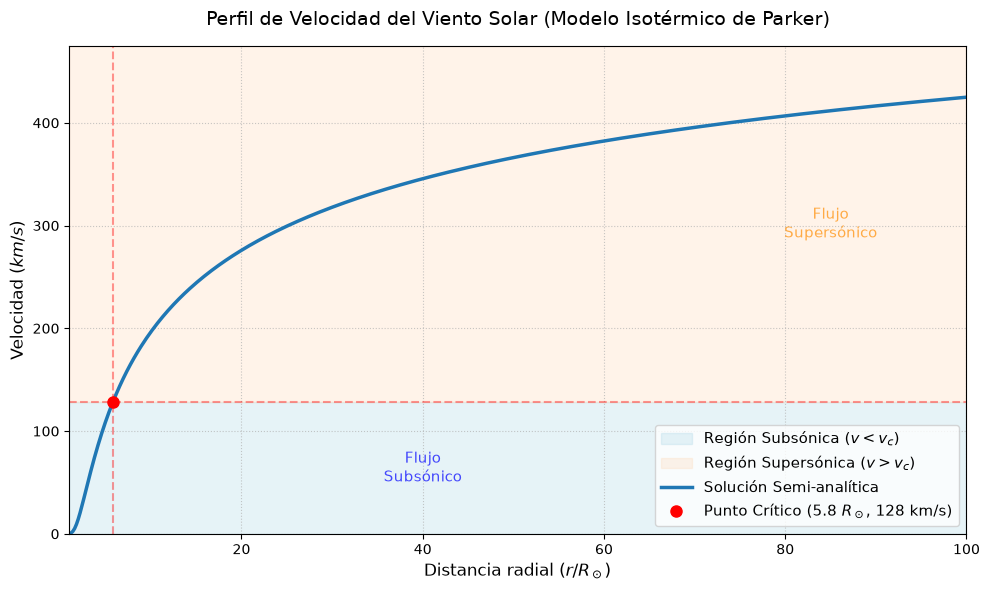

In [35]:
#Grafica - analytical solution plot
# Crear la figura
plt.figure(figsize=(10, 6))

# Definir el punto crítico en las unidades de la gráfica
r_c_Rsun = 5.8
v_c_kms = 128.0
y_max = max(v_solucion_kms) + 50

# 1. Sombrear las regiones HORIZONTALMENTE (Eje Y: Velocidad)
# Fondo azul claro desde v = 0 hasta v = v_c (Subsónico)
plt.axhspan(0, v_c_kms, color='lightblue', alpha=0.3, label='Región Subsónica ($v < v_c$)')
# Fondo naranja claro desde v = v_c hasta el límite superior (Supersónico)
plt.axhspan(v_c_kms, y_max, color='peachpuff', alpha=0.3, label='Región Supersónica ($v > v_c$)')

# Textos flotantes para las regiones (ajustados a las nuevas franjas)
plt.text(40, v_c_kms / 2, 'Flujo\nSubsónico', 
         fontsize=11, color='blue', ha='center', va='center', alpha=0.7)
plt.text(85, (v_c_kms + y_max) / 2, 'Flujo\nSupersónico', 
         fontsize=11, color='darkorange', ha='center', va='center', alpha=0.7)

# Graficar la solución principal
plt.plot(r_array_Rsun, v_solucion_kms, label='Solución Semi-analítica', color='#1f77b4', linewidth=2.5)

# Resaltar el punto crítico con un marcador rojo
plt.plot(r_c_Rsun, v_c_kms, 'ro', markersize=8, label='Punto Crítico (5.8 $R_\\odot$, 128 km/s)')

# Añadir líneas punteadas de referencia para el punto crítico
plt.axvline(x=r_c_Rsun, color='red', linestyle='--', alpha=0.4)
plt.axhline(y=v_c_kms, color='red', linestyle='--', alpha=0.4)

# Configurar etiquetas y título
plt.title('Perfil de Velocidad del Viento Solar (Modelo Isotérmico de Parker)', fontsize=14, pad=15)
plt.xlabel('Distancia radial ($r / R_\\odot$)', fontsize=12)
plt.ylabel('Velocidad ($km/s$)', fontsize=12)

# Ajustar los límites de los ejes
plt.xlim(1, 100)
plt.ylim(0, y_max)

# Diseño adicional para mayor claridad
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

# Mostrar la gráfica
plt.show()